# Working with complicated dataset

Your name: Angie Avalos Joel

### Question 1

blast_results: https://raw.githubusercontent.com/csbfx/advpy122-data/master/blast_results.csv

Read in the data from the csv file above. Skip all the comment lines, create a header for the dataframe based on the fields list in the comment line that starts with **# Fields:**. Drop the first column `query acc.ver`. Set the `subject acc.ver` as the index of the dataframe. The last column of the dataframe should be `publications`. Show the first five rows of the resulting dataframe.

In [1]:
import pandas as pd
blast_results = "https://raw.githubusercontent.com/csbfx/advpy122-data/master/blast_results.csv"

In [2]:
blast=pd.read_csv(blast_results)

In [3]:
blast.head()

,# blastp,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15
0,# Iteration: 0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,# Query: YP_220550.1 NADH dehydrogenase subuni...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,# RID: 9SW3UNUT015,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,# Database: nr,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,"# Fields: query acc.ver, subject acc.ver, % id...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
import urllib.request

### Read the first few lines
with urllib.request.urlopen(blast_results) as response:
    for i in range(15):
        line = response.readline().decode('utf-8').strip()
        print(f"{i + 1}: {line}")

1: # blastp,,,,,,,,,,,,,,,
2: # Iteration: 0,,,,,,,,,,,,,,,
3: # Query: YP_220550.1 NADH dehydrogenase subunit 1 (mitochondrion) [Mus musculus domesticus],,,,,,,,,,,,,,,
4: # RID: 9SW3UNUT015,,,,,,,,,,,,,,,
5: # Database: nr,,,,,,,,,,,,,,,
6: "# Fields: query acc.ver, subject acc.ver, % identity, alignment length, mismatches, gap opens, q. start, q. end, s. start, s. end, evalue, bit score, % positives, bonds, publications",,,,,,,,,,,,,,,
7: # 100 hits found,,,,,,,,,,,,,,,
8: YP_220550.1,NP_904328.1,100,318,0,0,1,318,1,318,0,629,100," 1,487 ",9,
9: YP_220550.1,AGK29621.1,99.686,318,1,0,1,318,1,318,0,629,100," 17,947 ",47,
10: YP_220550.1,YP_220563.1,99.686,318,1,0,1,318,1,318,0,627,100," 12,106 ",13,
11: YP_220550.1,ACM24502.1,99.686,318,1,0,1,318,1,318,0,627,99.69," 2,319 ",41,
12: YP_220550.1,AHG32084.1,99.371,318,2,0,1,318,1,318,0,627,100," 18,964 ",3,
13: YP_220550.1,AEN03421.1,99.686,318,1,0,1,318,1,318,0,626,99.69," 12,444 ",39,
14: YP_220550.1,6G2J_H,100,317,0,0,2,318,2,318,0,62

In [5]:
# Skip all the comment lines, create a header for the dataframe based on the fields
#list in the comment line that starts with # Fields:. Drop the first column
#query acc.ver. Set the subject acc.ver as the index of the dataframe. The last
#column of the dataframe should be publications.
#Show the first five rows of the resulting dataframe.

column_names = ["# Fields: query acc.ver", "subject acc.ver", "% identity", "alignment length", "mismatches", "gap opens", "q. start", "q. end", "s. start", "s. end", "evalue", "bit score", "% positives", "bonds", "publications",""]
blastResults = pd.read_csv(blast_results,
                      names=column_names,
                      skipfooter=1,
                      engine='python',
                      comment="#", # lines starts with # is considered
                      thousands=","
                     )
blastResults = blastResults.drop(columns=["# Fields: query acc.ver", ""])
blastResults = blastResults.set_index("subject acc.ver")
blastResults.head()


,% identity,alignment length,mismatches,gap opens,q. start,q. end,s. start,s. end,evalue,bit score,% positives,bonds,publications
subject acc.ver,,,,,,,,,,,,,
NP_904328.1,100.000,318,0,0,1,318,1,318,0,629,100.00,1487,9
AGK29621.1,99.686,318,1,0,1,318,1,318,0,629,100.00,17947,47
YP_220563.1,99.686,318,1,0,1,318,1,318,0,627,100.00,12106,13
ACM24502.1,99.686,318,1,0,1,318,1,318,0,627,99.69,2319,41
AHG32084.1,99.371,318,2,0,1,318,1,318,0,627,100.00,18964,3


In [6]:
print(blastResults.columns)
print(blastResults.head())

Index(['% identity', 'alignment length', 'mismatches', 'gap opens', 'q. start',
       'q. end', 's. start', 's. end', 'evalue', 'bit score', '% positives',
       'bonds', 'publications'],
      dtype='object')
                 % identity  alignment length  mismatches  gap opens  \
subject acc.ver                                                        
NP_904328.1         100.000               318           0          0   
AGK29621.1           99.686               318           1          0   
YP_220563.1          99.686               318           1          0   
ACM24502.1           99.686               318           1          0   
AHG32084.1           99.371               318           2          0   

                 q. start  q. end  s. start  s. end  evalue  bit score  \
subject acc.ver                                                          
NP_904328.1             1     318         1     318       0        629   
AGK29621.1              1     318         1     318       0  

### Question 2
What is the average number of publications?

In [7]:
blastResults["publications"]=pd.to_numeric(blastResults["publications"], errors='coerce')
blastResults["publications"].mean()

np.float64(26.9375)

The average number of publications is 26.94

### Question 3
List the `subject acc.ver` that has over 15,000 bonds.

In [8]:
blastResults[blastResults["bonds"]>15000].index

Index(['AGK29621.1', 'AHG32084.1', '6G2J_H', 'YP_002791042.1', 'AGK29634.1',
       '0806162F', 'YP_009112408.1', 'YP_001876469.1', 'YP_009092269.1',
       'AHG32149.1', 'YP_009092074.1', 'YP_009450474.1', 'YP_004123270.1',
       'YP_009092073.1', 'AHZ60901.1', 'YP_004123350.1', 'YP_009453754.1',
       'ADD46492.1', 'YP_007025968.1', 'YP_009453806.1', 'YP_007024956.1',
       'ASM92364.1', 'YP_006073044.1', 'ASM92494.1', 'ADG95699.1',
       'YP_004891275.1', 'YP_009166014.1', 'YP_009538416.1', 'YP_009414182.1',
       'YP_009178854.1', 'YP_009414415.1', 'YP_009353908.1', 'YP_009093743.1',
       'ABX45285.1', 'YP_009414156.1', 'YP_009414363.1'],
      dtype='object', name='subject acc.ver')

### Question 4
Create a plot that shows the correlation between `% identity` and `% positives`.

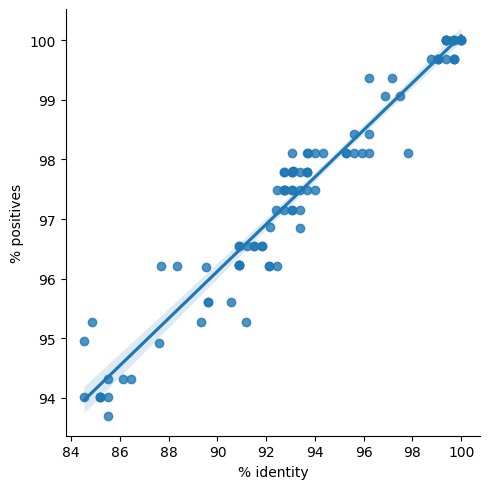

In [9]:
import seaborn as sns
g=sns.lmplot(
    data=blastResults,
    x="% identity",
    y="% positives",

)

There is a strong positive correlation between `% identity` and `% positive`. As `% idenity` increases `% positive` increases.

### Question  5
Add a column `Protein source` to the dataframe from Question 1 based on the data in this csv file: https://raw.githubusercontent.com/csbfx/advpy122-data/master/protein_source.csv. Merge the data when the `subject acc.ver` from the dataframe equals to `Protein` in the csv file. Entries without a matching protein will have `NA` as `Protein source`.

In [10]:
protein_source = "https://raw.githubusercontent.com/csbfx/advpy122-data/master/protein_source.csv"
proteinSource = pd.read_csv(protein_source)
proteinSource.head()

,Unnamed: 0,Protein,Source
0,0,NP_904328.1,RefSeq
1,2,YP_220563.1,GenPept
2,12,YP_002791042.1,GenPept
3,13,YP_001686698.1,GenPept
4,21,YP_009112408.1,GenPept


In [12]:
protein= proteinSource.set_index("Protein")["Source"]
blastResults["Protein source"] = protein
blastResults.head()


,% identity,alignment length,mismatches,gap opens,q. start,q. end,s. start,s. end,evalue,bit score,% positives,bonds,publications,Protein source
subject acc.ver,,,,,,,,,,,,,,
NP_904328.1,100.000,318,0,0,1,318,1,318,0,629,100.00,1487,9.0,RefSeq
AGK29621.1,99.686,318,1,0,1,318,1,318,0,629,100.00,17947,47.0,NaN
YP_220563.1,99.686,318,1,0,1,318,1,318,0,627,100.00,12106,13.0,GenPept
ACM24502.1,99.686,318,1,0,1,318,1,318,0,627,99.69,2319,41.0,NaN
AHG32084.1,99.371,318,2,0,1,318,1,318,0,627,100.00,18964,3.0,NaN
